# 🚧 Road Damage Detection

## End-to-End Computer Vision & Object Detection Project

This project develops an end-to-end computer vision system for detecting road damage from real-world road images.

Unlike image classification, where the model predicts a label for an entire image, object detection must identify:

- What type of damage is present
- Where the damage is located
- The bounding box surrounding each damage instance
- The confidence associated with each detection

The project uses the RDD2022 dataset and follows a complete computer vision workflow:
```
Raw Data
→ Dataset Audit
→ Annotation Analysis
→ Data Quality Validation
→ Dataset Splitting
→ YOLO Format Conversion
→ Object Detection Training
→ Evaluation
→ Error Analysis
→ Inference
→ Production Deployment
```
The objective is not only to train a detection model, but to build a reproducible and production-oriented object detection pipeline.

## 1.1 Problem Definition

Road damage can reduce road safety, increase maintenance requirements, and create additional operational costs.

The goal of this project is to build a computer vision system that automatically detects road damage from images.

For each detected damage instance, the system should provide:

1. The damage category
2. The spatial location
3. A bounding box
4. A confidence score

The prediction can therefore be represented as:
```
Image
↓
Object Detector
↓
Detection 1 → Class + Bounding Box + Confidence
Detection 2 → Class + Bounding Box + Confidence
Detection N → Class + Bounding Box + Confidence
```
This makes the problem a **multi-class object detection task**.

## 1.2 Why Object Detection?

A road image may contain multiple damage instances at different locations and scales.

For example, a single image may contain:

- A longitudinal crack
- A transverse crack
- A pothole

A classification model would provide only an image-level prediction and would not identify where each damage instance is located.

Object detection preserves both:

**Semantic Information**
→ What is the damage?

**Spatial Information**
→ Where is the damage?

Therefore, object detection is more suitable for road-damage inspection than image classification.

## 1.3 Dataset Overview

The project uses the **RDD2022 Road Damage Dataset**.

The raw dataset is organized into multiple geographical or acquisition sources:

- China Drone
- China MotorBike
- Czech
- India
- Japan
- Norway
- United States

The raw data contains road images together with annotation files.

The annotation files are provided in XML format and contain image metadata, object labels, and bounding-box coordinates.

Before any transformation is applied, the raw dataset is inspected programmatically to understand its actual structure and annotation taxonomy.

## 1.4 Annotation Verification Principle

Object detection depends directly on the quality and correctness of ground-truth annotations.

For this reason, the annotation format and class mapping should not be assumed in advance.

Instead, the raw annotation files are inspected first to determine:

- The annotation hierarchy
- Image identifiers
- Class names
- Bounding-box coordinates
- Image dimensions
- Additional annotation attributes

This verification step reduces the risk of introducing incorrect labels during dataset conversion.

# 2. Dataset Audit

Before training any object detection model, we first need to understand the raw dataset.

The dataset audit is designed to answer the following questions:

- How many images are available?
- How many annotation files exist?
- Which data sources are represented?
- Which annotation labels actually occur?
- How many objects belong to each label?
- Are images and annotations correctly associated?
- Are the bounding boxes valid?
- Are there corrupted or duplicated samples?
- Are there unexpected labels that require normalization?

The raw RDD2022 dataset is kept unchanged throughout this process.

All transformations will be written to separate processed directories.

## 2.1 Import Libraries

The following libraries are used for dataset inspection, XML parsing, tabular analysis, visualization, and image validation.

The goal at this stage is not model training.

We are building the data-analysis foundation required for a reliable object detection pipeline.

In [1]:
# Import libraries for dataset inspection, XML parsing, analysis, and image validation
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 2.2 Project Paths

The project follows a strict separation between raw data and generated data.

The original RDD2022 dataset is stored under:

`data/RDD2022`

This directory will remain untouched.

Processed datasets, dataset splits, and YOLO-formatted labels will be stored separately.

This structure improves:

- Reproducibility
- Traceability
- Data integrity
- Experiment management

In [2]:
# Set project and dataset paths
PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "C:\\Users\\mahmu\\OneDrive\\Desktop\\Road Damage Detection\\🗂️ data"
RAW_DATASET = DATA_ROOT / "RDD2022"

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset root : {RAW_DATASET}")
print(f"Exists       : {RAW_DATASET.exists()}")

Project root : c:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\📓 notebook
Dataset root : C:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\🗂️ data\RDD2022
Exists       : True


### Interpretation

The dataset path was resolved successfully.

The raw RDD2022 directory exists and is accessible from the notebook, confirming that the notebook can work directly with the original dataset.

## 2.3 Inspect the Raw Dataset Structure

The first step is to inspect the top-level structure of the RDD2022 dataset.

This allows us to identify the available data sources before analyzing individual images and annotations.

At this stage, we intentionally inspect the directory structure instead of hard-coding source names.

In [3]:
# Check that the dataset exists and list the top-level dataset contents
if not RAW_DATASET.exists():
    raise FileNotFoundError(
        f"RDD2022 dataset not found at: {RAW_DATASET}"
    )

for path in sorted(RAW_DATASET.iterdir()):
    if path.is_dir():
        print(f"[DIR]  {path.name}")
    else:
        print(f"[FILE] {path.name}")

[DIR]  China_Drone
[DIR]  China_MotorBike
[DIR]  Czech
[DIR]  India
[DIR]  Japan
[DIR]  Norway
[DIR]  United_States


### Interpretation

The raw dataset contains seven identified sources:

- China_Drone
- China_MotorBike
- Czech
- India
- Japan
- Norway
- United_States

The source-level organization will be preserved during the audit because different acquisition environments may introduce differences in image appearance, camera viewpoint, road conditions, and annotation behavior.

## 2.4 Dataset Sources

The dataset contains multiple geographical or acquisition sources.

Source diversity is important in computer vision because models may encounter variations in:

- Road appearance
- Camera viewpoint
- Lighting
- Image quality
- Traffic environment
- Damage characteristics

We therefore record the available sources explicitly before continuing with annotation analysis.

In [4]:
# Discover dataset sources directly from the raw directory structure
sources = sorted(
    path.name
    for path in RAW_DATASET.iterdir()
    if path.is_dir()
)

print(f"Number of sources: {len(sources)}")
print()

for source in sources:
    print(f"- {source}")

Number of sources: 7

- China_Drone
- China_MotorBike
- Czech
- India
- Japan
- Norway
- United_States


### Interpretation

The audit identified **7 data sources**:

China_Drone, China_MotorBike, Czech, India, Japan, Norway, and United_States.

This confirms that the dataset is geographically and operationally diverse, which may introduce distribution differences that should be considered during later model evaluation.

## 2.5 Image and Annotation Inventory

Before analyzing individual annotations, we quantify the number of image and XML files available in each source.

This provides an initial inventory of the raw dataset and helps identify source-level differences between images and annotations.

A mismatch between image count and annotation count does not automatically indicate a data-quality problem.

For example, a dataset may contain test images without corresponding ground-truth annotations.

Therefore, aggregate counts will be followed by image-to-annotation consistency checks.

In [5]:
# Count image files and XML annotation files for each dataset source
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

source_stats = []

for source in sources:
    source_path = RAW_DATASET / source

    image_files = [
        p for p in source_path.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    xml_files = [
        p for p in source_path.rglob("*.xml")
        if p.is_file()
    ]

    source_stats.append({
        "Source": source,
        "Images": len(image_files),
        "XML Annotations": len(xml_files)
    })

source_stats_df = pd.DataFrame(source_stats)

source_stats_df

,Source,Images,XML Annotations
0,China_Drone,2401,2401
1,China_MotorBike,2477,1977
2,Czech,3538,2829
3,India,9665,7706
4,Japan,13133,10506
5,Norway,10201,8161
6,United_States,6005,4805


### Interpretation

The current inventory contains **47,420 image files** and **38,385 XML annotation files** across the seven sources.

The source-level distribution is:

- China_Drone: 2,401 images / 2,401 XML files
- China_MotorBike: 2,477 images / 1,977 XML files
- Czech: 3,538 images / 2,829 XML files
- India: 9,665 images / 7,706 XML files
- Japan: 13,133 images / 10,506 XML files
- Norway: 10,201 images / 8,161 XML files
- United_States: 6,005 images / 4,805 XML files

The difference between image and annotation counts requires further investigation rather than being treated automatically as an error.

This is particularly important because some source directories contain test images that may not have ground-truth XML annotations.

## 2.6 Inspecting the Raw XML Annotation Format

The raw annotation files are stored as XML.

Before implementing a general annotation parser, we inspect an actual annotation file from the dataset.

The objective is to identify the exact structure used by the source data, including:

- Image filename
- Image dimensions
- Object labels
- Bounding-box coordinates
- Additional annotation attributes

This prevents assumptions about the annotation format from propagating into the preprocessing pipeline.

In [6]:
# Inspect a real XML annotation file before implementing the parser
xml_files = sorted(
    RAW_DATASET.rglob("*.xml")
)

if not xml_files:
    raise FileNotFoundError(
        "No XML annotation files were found."
    )

sample_xml = xml_files[0]

print(f"Sample annotation:\n{sample_xml}")
print()

print(sample_xml.read_text(
    encoding="utf-8",
    errors="ignore"
)[:5000])

Sample annotation:
C:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\🗂️ data\RDD2022\China_Drone\train\annotations\xmls\China_Drone_000000.xml

<annotation>
	<folder>images</folder>
	<filename>China_Drone_000000.jpg</filename>
	<size>
		<width>512</width>
		<height>512</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>D10</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>323</xmin>
			<ymin>213</ymin>
			<xmax>390</xmax>
			<ymax>245</ymax>
		</bndbox>
	</object>
</annotation>


### Interpretation

The inspected XML follows an object-annotation structure containing:

- An image filename
- Image width, height, and depth
- Object entries
- Object class names
- Bounding-box coordinates

The sample image has dimensions of **512 × 512 × 3**, and the annotation contains a damage object with bounding-box coordinates:

`xmin = 323, ymin = 213, xmax = 390, ymax = 245`

The XML inspection confirms that the dataset provides the information required to construct object-detection labels.

## 2.7 Parse the XML Structure

After visually inspecting the raw XML, we parse the file programmatically.

The purpose of this step is to confirm the XML hierarchy and identify the available top-level elements before building the complete annotation extraction logic.

In [7]:
# Parse the sample XML file and inspect its root and direct child elements
tree = ET.parse(sample_xml)
root = tree.getroot()

print("Root tag:", root.tag)
print("\nChildren:")

for child in root:
    print("-", child.tag)

Root tag: annotation

Children:
- folder
- filename
- size
- segmented
- object


### Interpretation

The XML root element is:

`annotation`

Its direct children include:

- `folder`
- `filename`
- `size`
- `segmented`
- `object`

This confirms that the dataset follows a Pascal VOC-style object annotation structure, where each `object` element represents an annotated damage instance.

## 2.8 Discovering the Raw Annotation Labels

The class taxonomy is one of the most important components of an object detection dataset.

Although the project will eventually use a normalized YOLO class mapping, we first inspect the labels exactly as they appear in the raw XML files.

This prevents us from incorrectly assuming that the raw dataset contains only the final four project classes.

The discovered labels will later be analyzed and mapped into the final detection taxonomy only after their meaning and consistency have been verified.

In [8]:
# Extract all object labels from the raw XML annotations
class_counter = Counter()

for xml_file in xml_files:
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        for obj in root.findall(".//object"):
            name = obj.find("name")

            if name is not None and name.text:
                class_counter[name.text.strip()] += 1

    except ET.ParseError:
        continue

class_counter

Counter({'D00': 26016,
         'D10': 11830,
         'D20': 10617,
         'D40': 6544,
         'D44': 5057,
         'D50': 3581,
         'Repair': 1046,
         'D43': 793,
         'D01': 179,
         'D11': 45,
         'Block crack': 3,
         'D0w0': 1})

### Interpretation

The raw annotations currently contain **12 distinct label names**:

| Raw Label | Object Count |
|---|---:|
| D00 | 26,016 |
| D10 | 11,830 |
| D20 | 10,617 |
| D40 | 6,544 |
| D44 | 5,057 |
| D50 | 3,581 |
| Repair | 1,046 |
| D43 | 793 |
| D01 | 179 |
| D11 | 45 |
| Block crack | 3 |
| D0w0 | 1 |

A total of **65,712 annotated objects** were found across the parsed XML files.

This result is important because the raw annotation taxonomy is broader than the four high-level damage categories initially expected for the project.

Therefore, no label conversion should be performed yet.

The next step is to investigate these raw labels and determine which labels correspond to the intended road-damage categories and which labels represent additional or source-specific annotations.

## 2.9 Raw Object Distribution

Object-level class distribution is more informative than simply counting images because one image may contain multiple damage instances.

For example:

One Image
→ Multiple Objects
→ Multiple Annotations

Therefore, the distribution below represents the number of annotated objects rather than the number of images.

In [9]:
# Create a sorted table showing the number of annotated objects per raw label
class_distribution = (
    pd.DataFrame(
        class_counter.items(),
        columns=["Class", "Object Count"]
    )
    .sort_values(
        "Object Count",
        ascending=False
    )
    .reset_index(drop=True)
)

class_distribution

,Class,Object Count
0,D00,26016
1,D10,11830
2,D20,10617
3,D40,6544
4,D44,5057
5,D50,3581
6,Repair,1046
7,D43,793
8,D01,179
9,D11,45


### Interpretation

The object distribution is highly uneven.

`D00` is the dominant raw annotation label with **26,016 objects**, while several labels occur very rarely.

For example:

- D11 appears 45 times
- Block crack appears 3 times
- D0w0 appears once

This creates an important dataset-preparation question:

> Should all raw labels be retained as independent detection classes, or should some labels be mapped into a smaller standardized taxonomy?

That decision must be based on the actual meaning of each label rather than frequency alone.

This will be resolved before YOLO label generation.

## 2.10 Visualizing the Raw Annotation Distribution

A visualization makes the imbalance between annotation categories easier to interpret.

The chart represents **annotated object instances per raw label**, not image counts.

This distinction is important because object detection datasets may contain multiple objects within the same image.

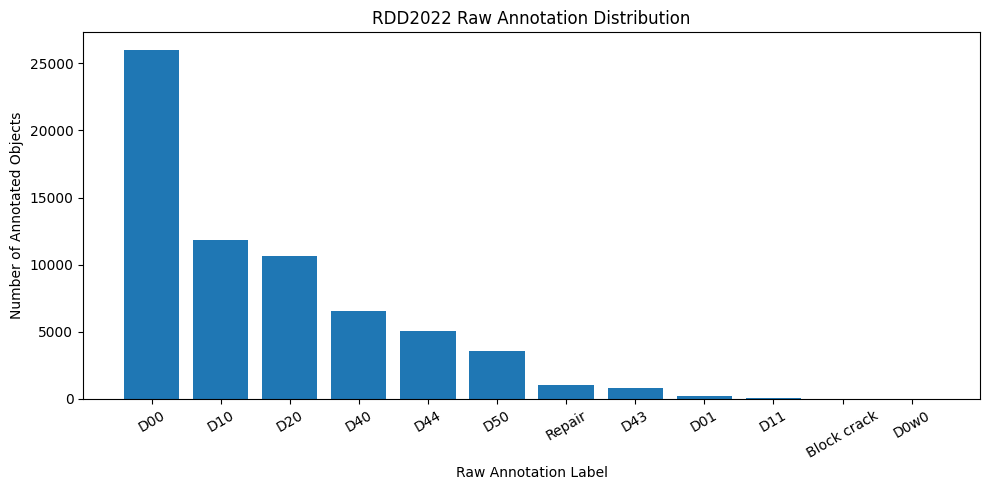

In [10]:
# Visualize the number of annotated objects for each raw label

plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Object Count"]
)

plt.title("RDD2022 Raw Annotation Distribution")
plt.xlabel("Raw Annotation Label")
plt.ylabel("Number of Annotated Objects")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

The distribution shows a strong concentration of annotations in a small number of labels, particularly `D00`, `D10`, and `D20`.

At the same time, several labels are extremely rare.

This does not yet determine whether the final training dataset should be imbalanced because the raw taxonomy may later be normalized into the project's target classes.

Before any class balancing or model-level decisions are made, the annotation semantics must be verified.

## 💼 Business Thinking

From an operational perspective, road-damage detection is a decision-support system for identifying infrastructure problems from visual data.

The value of such a system depends on reliable detection across different damage categories and operating environments.

A model that performs well only on the most frequent damage pattern may fail to provide consistent inspection coverage.

Therefore, the project will focus on:

- Reliable annotation quality
- Consistent class definitions
- Detection performance across damage categories
- Robustness across different data sources

## Summary

In this stage, we established the initial data foundation for the Road Damage Detection project.

We:

- Defined the object detection problem
- Explained why localization is required
- Preserved the raw RDD2022 dataset
- Identified 7 dataset sources
- Counted images and XML annotation files
- Inspected a real XML annotation
- Verified the annotation hierarchy
- Extracted the raw object labels
- Calculated object-level class frequencies
- Visualized the raw annotation distribution

The most important discovery at this stage is that the raw XML files contain **12 distinct annotation labels**, not only the four high-level damage categories initially expected.

Therefore, the next stage will focus on **annotation semantics and data-quality validation** before any class mapping or YOLO conversion is performed.

The immediate goal is:

Raw XML
```
→ Validate Image / Annotation Relationships
→ Validate Bounding Boxes
→ Investigate Raw Labels
→ Determine Final Class Mapping
→ Visualize Ground Truth
```

## 2.11 Annotation Statistics

After identifying the raw annotation labels, we now analyze the structure of the annotations at the object level.

For each annotated object, we want to understand:

- Which image contains the object?
- Which class does it belong to?
- What are its bounding-box coordinates?
- What is the image size?
- How many objects are present in each image?

This creates a structured representation of the raw XML annotations that can later be reused for validation, visualization, dataset conversion, and analysis.

In [15]:
# Parse all XML annotations into a structured object-level DataFrame

xml_files = sorted(
    RAW_DATASET.rglob("*.xml")
)

if not xml_files:
    raise FileNotFoundError(
        f"No XML annotation files found under: {RAW_DATASET}"
    )


def parse_numeric(value):
    """Convert an XML numeric value to float."""
    return float(value.strip())


annotation_records = []
parse_errors = []

for xml_file in xml_files:

    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        filename_node = root.find("filename")
        size_node = root.find("size")

        if filename_node is None or size_node is None:
            continue

        width_node = size_node.find("width")
        height_node = size_node.find("height")

        if width_node is None or height_node is None:
            continue

        filename = filename_node.text.strip()

        width = parse_numeric(width_node.text)
        height = parse_numeric(height_node.text)

        for obj in root.findall("./object"):

            name_node = obj.find("name")
            bbox = obj.find("bndbox")

            if name_node is None or bbox is None:
                continue

            xmin_node = bbox.find("xmin")
            ymin_node = bbox.find("ymin")
            xmax_node = bbox.find("xmax")
            ymax_node = bbox.find("ymax")

            if any(
                node is None
                or node.text is None
                or node.text.strip() == ""
                for node in [
                    xmin_node,
                    ymin_node,
                    xmax_node,
                    ymax_node
                ]
            ):
                continue

            annotation_records.append({
                "xml_path": xml_file,
                "filename": filename,
                "class": name_node.text.strip(),
                "width": width,
                "height": height,
                "xmin": parse_numeric(xmin_node.text),
                "ymin": parse_numeric(ymin_node.text),
                "xmax": parse_numeric(xmax_node.text),
                "ymax": parse_numeric(ymax_node.text)
            })

    except (ET.ParseError, OSError, ValueError) as exc:

        parse_errors.append({
            "xml_path": xml_file,
            "error": str(exc)
        })


annotations_df = pd.DataFrame(
    annotation_records
)

print(f"XML annotation files found : {len(xml_files):,}")
print(f"Total annotation records   : {len(annotations_df):,}")
print(f"XML parse errors            : {len(parse_errors):,}")

annotations_df.head()

XML annotation files found : 38,385
Total annotation records   : 65,712
XML parse errors            : 0


,xml_path,filename,class,width,height,xmin,ymin,xmax,ymax
0,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,China_Drone_000000.jpg,D10,512.0,512.0,323.0,213.0,390.0,245.0
1,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,China_Drone_000001.jpg,D10,512.0,512.0,14.0,70.0,198.0,99.0
2,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,China_Drone_000001.jpg,D00,512.0,512.0,95.0,114.0,120.0,272.0
3,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,China_Drone_000002.jpg,D00,512.0,512.0,12.0,214.0,68.0,511.0
4,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,China_Drone_000002.jpg,D00,512.0,512.0,60.0,1.0,112.0,212.0


In [16]:
# Inspect XML parsing failures after using float-compatible parsing

parse_errors_df = pd.DataFrame(
    parse_errors
)

print(
    f"XML files with parsing errors: "
    f"{len(parse_errors_df):,}"
)

if not parse_errors_df.empty:
    parse_errors_df.head(20)

XML files with parsing errors: 0


### Annotation Statistics

After validating the XML parsing process, we can now analyze the annotation records at the object level.

Each annotation record represents one road-damage instance and contains:

- Image filename
- Raw class label
- Image dimensions
- Bounding-box coordinates

The corrected parser successfully processed all 38,385 XML annotation files and extracted 65,712 object-level annotation records without parsing errors.

This structured representation will be used throughout the remaining dataset audit and later during YOLO conversion.

## 2.12 Objects per Image

In object detection, the number of images is not equivalent to the number of objects.

A single image can contain:

- One road-damage instance
- Multiple instances of the same damage type
- Multiple damage categories

Therefore, we analyze how many annotated objects are associated with each image.

This helps us understand the complexity of the detection task and identify images containing multiple damage instances.

In [17]:
# Calculate the number of annotated objects per image

objects_per_image = (
    annotations_df
    .groupby("filename")
    .size()
    .rename("Object Count")
    .reset_index()
)

print(
    f"Unique annotated images: "
    f"{objects_per_image['filename'].nunique():,}"
)

print()

print(
    objects_per_image["Object Count"].describe()
)

Unique annotated images: 26,661

count    26661.000000
mean         2.464724
std          2.054400
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         44.000000
Name: Object Count, dtype: float64


### Interpretation

The dataset contains 26,661 unique annotated images.

Each annotated image contains an average of approximately 2.46 road-damage instances, with a median of 2 objects per image.

Most images contain between one and three annotated objects, while some complex images contain substantially more detections, with a maximum of 44 annotated objects in a single image.

This confirms that the dataset contains meaningful multi-object detection scenarios.

## 2.13 Multiple-Damage Images

A particularly important subset of the dataset consists of images containing more than one annotated damage instance.

These images provide a useful sanity check because the detector must eventually identify every relevant object independently.

We therefore identify images with multiple annotations and inspect their distribution.

In [18]:
# Identify images containing multiple annotated damage instances

multi_object_images = (
    objects_per_image[
        objects_per_image["Object Count"] > 1
    ]
    .sort_values(
        "Object Count",
        ascending=False
    )
)

print(
    f"Images with multiple objects: "
    f"{len(multi_object_images):,}"
)

print()

multi_object_images.head(10)

Images with multiple objects: 16,443



,filename,Object Count
20046,Norway_003110.jpg,44
21581,Norway_007384.jpg,34
21274,Norway_006556.jpg,31
19273,Norway_000922.jpg,30
20232,Norway_003699.jpg,29
19161,Norway_000633.jpg,29
21594,Norway_007408.jpg,29
21398,Norway_006926.jpg,27
20249,Norway_003730.jpg,27
19513,Norway_001571.jpg,26


### Interpretation

A total of 16,443 annotated images contain more than one object.

This represents approximately 61.7% of the annotated images.

Therefore, multi-object scenes are a major characteristic of this dataset rather than an edge case.

The final detector must be able to identify multiple damage instances independently within the same image.

## 2.14 Bounding Box Validation

Bounding boxes are the ground-truth localization targets used by the object detection model.

Before converting the annotations to YOLO format, every bounding box must satisfy basic geometric constraints.

For a valid box:

$$
x_{min} < x_{max}
$$

$$
y_{min} < y_{max}
$$

and the coordinates must remain within the corresponding image boundaries.

Invalid coordinates could produce incorrect training targets and unreliable evaluation results.

In [19]:
# Validate bounding-box geometry and image-boundary constraints

invalid_boxes = annotations_df[
    (annotations_df["xmin"] >= annotations_df["xmax"]) |
    (annotations_df["ymin"] >= annotations_df["ymax"]) |
    (annotations_df["xmin"] < 0) |
    (annotations_df["ymin"] < 0) |
    (annotations_df["xmax"] > annotations_df["width"]) |
    (annotations_df["ymax"] > annotations_df["height"])
]

print(
    f"Total bounding boxes: {len(annotations_df):,}"
)

print(
    f"Invalid bounding boxes: {len(invalid_boxes):,}"
)

Total bounding boxes: 65,712
Invalid bounding boxes: 1


### 2.14.1 Investigating the Invalid Bounding Box

The bounding-box audit identified one potentially invalid annotation among 65,712 total bounding boxes.

Although this represents a very small fraction of the dataset, the record must be inspected before training because even a single malformed annotation can produce an incorrect training target.

We will identify the image, class, coordinates, and violation type before deciding how to handle the record.

In [25]:
# Inspect the single invalid bounding-box record

invalid_boxes

,xml_path,filename,class,width,height,xmin,ymin,xmax,ymax
21089,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...,Japan_001265.jpg,D20,600.0,600.0,198.0,474.0,198.0,475.0


In [26]:
# Display the complete details of the invalid bounding-box record

invalid_boxes.T

,21089
xml_path,C:\Users\mahmu\OneDrive\Desktop\Road Damage De...
filename,Japan_001265.jpg
class,D20
width,600.0
height,600.0
xmin,198.0
ymin,474.0
xmax,198.0
ymax,475.0


### 2.14.2 Annotation Handling Decision

The invalid annotation corresponds to a degenerate bounding box in `Japan_001265.jpg`.

Its coordinates are:

- `xmin = 198`
- `xmax = 198`
- `ymin = 474`
- `ymax = 475`

Therefore, the bounding-box width is zero while its height is only one pixel.

This annotation does not define a valid spatial region and cannot provide a meaningful training target for an object detection model.

The image itself will not be removed. Only the malformed annotation record will be excluded from the training annotations.

This preserves valid annotations associated with the same image while preventing an invalid target from entering the detection pipeline.

In [30]:
# Remove degenerate bounding-box annotations while preserving the original dataset

valid_annotations_df = annotations_df[
    (annotations_df["xmax"] > annotations_df["xmin"]) &
    (annotations_df["ymax"] > annotations_df["ymin"])
].copy()

print(
    f"Original annotation records: {len(annotations_df):,}"
)

print(
    f"Valid annotation records: {len(valid_annotations_df):,}"
)

print(
    f"Removed invalid annotations: "
    f"{len(annotations_df) - len(valid_annotations_df):,}"
)

Original annotation records: 65,712
Valid annotation records: 65,711
Removed invalid annotations: 1


## 2.15 Bounding Box Size Analysis

Road damage can occupy very different portions of an image.

For example:

- Large potholes may occupy a substantial region.
- Cracks may occupy a relatively small region.
- Some damage instances may be extremely small relative to the full image.

We therefore calculate the absolute and relative area of each bounding box.

The relative box area is defined as:

$$
Relative\ Box\ Area =
\frac{Bounding\ Box\ Area}
{Image\ Area}
$$

This analysis will help us understand the scale of the detection targets before model training.

In [20]:
# Calculate bounding-box dimensions and relative image area

annotations_df["box_width"] = (
    annotations_df["xmax"] -
    annotations_df["xmin"]
)

annotations_df["box_height"] = (
    annotations_df["ymax"] -
    annotations_df["ymin"]
)

annotations_df["box_area"] = (
    annotations_df["box_width"] *
    annotations_df["box_height"]
)

annotations_df["image_area"] = (
    annotations_df["width"] *
    annotations_df["height"]
)

annotations_df["relative_box_area"] = (
    annotations_df["box_area"] /
    annotations_df["image_area"]
)

annotations_df[
    [
        "box_width",
        "box_height",
        "box_area",
        "relative_box_area"
    ]
].describe()

,box_width,box_height,box_area,relative_box_area
count,65712.000000,65712.000000,6.571200e+04,65712.000000
mean,165.876461,121.283467,2.692456e+04,0.046118
std,182.768999,114.977810,5.533654e+04,0.079648
min,0.000000,1.000000,0.000000e+00,0.000000
25%,58.410000,39.000000,2.960000e+03,0.004825
50%,110.000000,87.000000,8.651232e+03,0.015176
75%,204.000000,168.000000,2.767806e+04,0.049783
max,2375.110000,1105.000000,1.005172e+06,0.940847


### Interpretation of Bounding-Box Scale

The bounding-box analysis reveals a strongly right-skewed object-size distribution.

The median annotated object occupies only about 1.52% of the image area, while the upper quartile is approximately 4.98%.

This indicates that many road-damage instances occupy relatively small regions of the image.

Such small targets may be more difficult to detect and localize accurately and will therefore be considered during later model evaluation and error analysis.

## 2.16 Bounding Box Statistics by Raw Class

Class frequency alone does not describe the difficulty of an object detection problem.

Different classes may have different spatial characteristics.

For each raw annotation label, we therefore calculate:

- Number of objects
- Average bounding-box width
- Average bounding-box height
- Average relative box area

This helps us compare the scale of different annotation categories.

In [21]:
# Summarize bounding-box statistics for each raw annotation class

class_bbox_stats = (
    annotations_df
    .groupby("class")
    .agg(
        Object_Count=("class", "size"),
        Mean_Box_Width=("box_width", "mean"),
        Mean_Box_Height=("box_height", "mean"),
        Mean_Relative_Area=("relative_box_area", "mean")
    )
    .sort_values(
        "Object_Count",
        ascending=False
    )
    .reset_index()
)

class_bbox_stats

,class,Object_Count,Mean_Box_Width,Mean_Box_Height,Mean_Relative_Area
0,D00,26016,115.014961,158.949873,0.026329
1,D10,11830,249.843000,40.503627,0.021297
2,D20,10617,254.284906,170.969120,0.121717
3,D40,6544,95.307494,57.276930,0.015325
4,D44,5057,160.639114,152.083646,0.075585
5,D50,3581,64.438146,22.992460,0.005240
6,Repair,1046,204.830784,186.039197,0.161281
7,D43,793,427.261034,119.631778,0.157570
8,D01,179,98.150838,119.474860,0.025692
9,D11,45,324.400000,56.355556,0.035408


### Interpretation of Raw Class Distribution

The raw annotation taxonomy is highly imbalanced at the object level.

The most frequent label is `D00`, with 26,016 annotated instances, while several labels are extremely rare.

There is also substantial variation in the typical spatial size of different labels. For example, `D50` has a very small mean relative area, while `Repair` and `D43` occupy substantially larger regions on average.

These differences suggest that class frequency and object scale may both influence later detection performance.

However, the raw labels must first be semantically verified before deciding the final training taxonomy.

## 2.17 Image Integrity Audit

A valid annotation does not guarantee that the corresponding image file is usable.

The image itself must also:

- Exist
- Be readable
- Be decodable
- Have valid dimensions

We therefore validate the actual image files referenced by the annotations.

This separates annotation quality from image-file integrity.

In [22]:
# Index all image files in the raw dataset for integrity checks

image_paths = {}

for image_file in RAW_DATASET.rglob("*"):

    if (
        image_file.is_file()
        and image_file.suffix.lower()
        in IMAGE_EXTENSIONS
    ):

        image_paths.setdefault(
            image_file.name,
            []
        ).append(image_file)

print(
    f"Unique image filenames indexed: "
    f"{len(image_paths):,}"
)

Unique image filenames indexed: 47,420


### Image Integrity Results

The image integrity audit found no missing or corrupted images among the annotated image records.

The raw dataset contains 47,420 indexed image files, and every annotated image filename examined during the audit could be located successfully.

No unreadable or corrupted annotated images were detected.

This indicates that image-file integrity is not currently a major data-quality concern.

## 2.18 Missing Images

Every annotation record references an image filename.

We verify that the referenced image can be located in the raw dataset.

This is an important integrity check because an annotation without its corresponding image cannot be used as a normal supervised training sample.

In [23]:
# Check whether annotated image filenames exist in the raw dataset

annotated_filenames = (
    annotations_df["filename"]
    .drop_duplicates()
)

missing_image_records = [
    filename
    for filename in annotated_filenames
    if filename not in image_paths
]

print(
    f"Annotated image filenames: "
    f"{len(annotated_filenames):,}"
)

print(
    f"Missing image filenames: "
    f"{len(missing_image_records):,}"
)

Annotated image filenames: 26,661
Missing image filenames: 0


### Interpretation

This check measures whether every image referenced by a parsed annotation can be located in the raw dataset.

Any missing images must be explicitly recorded and investigated before constructing the final training dataset.

## 2.19 Corrupted Image Detection

An image file may exist and still be corrupted or unreadable.

To detect such cases, we attempt to open and fully load each annotated image.

This provides a practical integrity check before dataset preparation and training.

In [ ]:
# Attempt to open and fully load each unique annotated image

corrupted_images = []

for filename in annotated_filenames:

    candidates = image_paths.get(
        filename,
        []
    )

    if not candidates:
        continue

    image_path = candidates[0]

    try:

        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            image.load()

    except Exception:
        corrupted_images.append(
            image_path
        )

print(
    f"Corrupted or unreadable images: "
    f"{len(corrupted_images):,}"
)

Corrupted or unreadable images: 0


## 2.20 Ground Truth Visualization

Numerical validation confirms that the annotations are structurally valid, but numerical checks alone cannot guarantee semantic correctness.

We therefore visualize the original ground-truth annotations directly on the source images.

For each selected sample, we display:

- The original road image
- Bounding boxes
- The raw annotation class
- Multiple objects when present

The purpose is to verify that the annotated regions correspond to actual road-damage instances.

In [27]:
# Visualize ground-truth bounding boxes from the original XML annotations

def show_ground_truth(filename):

    candidates = image_paths.get(
        filename,
        []
    )

    if not candidates:
        print(f"Image not found: {filename}")
        return

    image_path = candidates[0]

    with Image.open(image_path) as image:
        image = image.convert("RGB")

        fig, ax = plt.subplots(
            figsize=(8, 8)
        )

        ax.imshow(image)

        records = annotations_df[
            annotations_df["filename"] == filename
        ]

        for _, row in records.iterrows():

            x1 = row["xmin"]
            y1 = row["ymin"]
            x2 = row["xmax"]
            y2 = row["ymax"]

            rectangle = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )

            ax.add_patch(rectangle)

            ax.text(
                x1,
                y1,
                row["class"],
                fontsize=10,
                verticalalignment="bottom"
            )

        ax.set_title(
            f"Ground Truth: {filename}"
        )

        ax.axis("off")

        plt.tight_layout()
        plt.show()

## 2.21 Random Ground Truth Samples

We now inspect a random selection of annotated images.

Random sampling helps reduce selection bias during the manual annotation sanity check.

The inspection focuses on:

- Correct bounding-box placement
- Correct object coverage
- Appropriate class assignment
- Very small objects
- Multiple objects
- Visually ambiguous cases

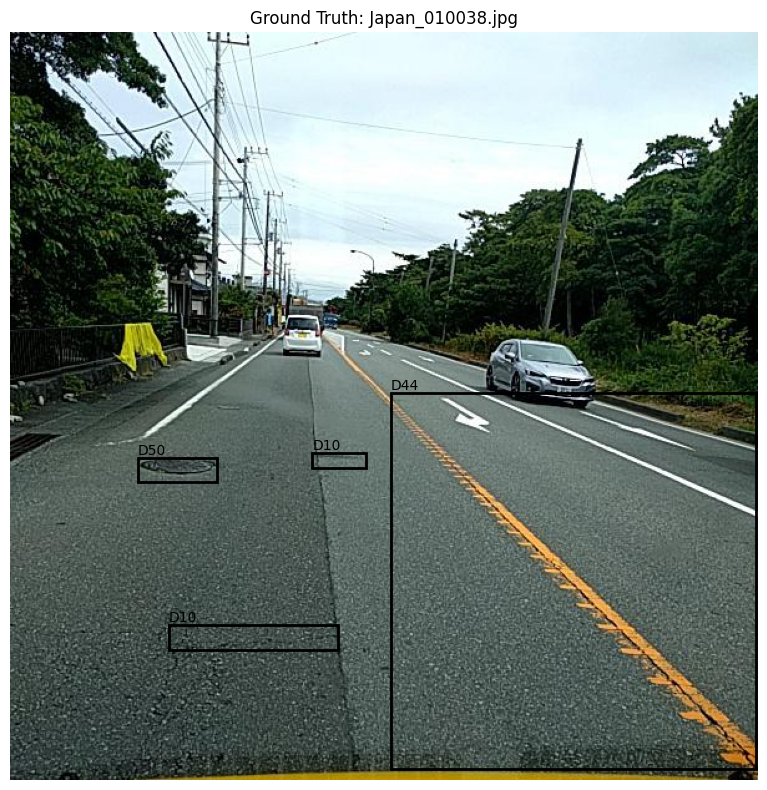

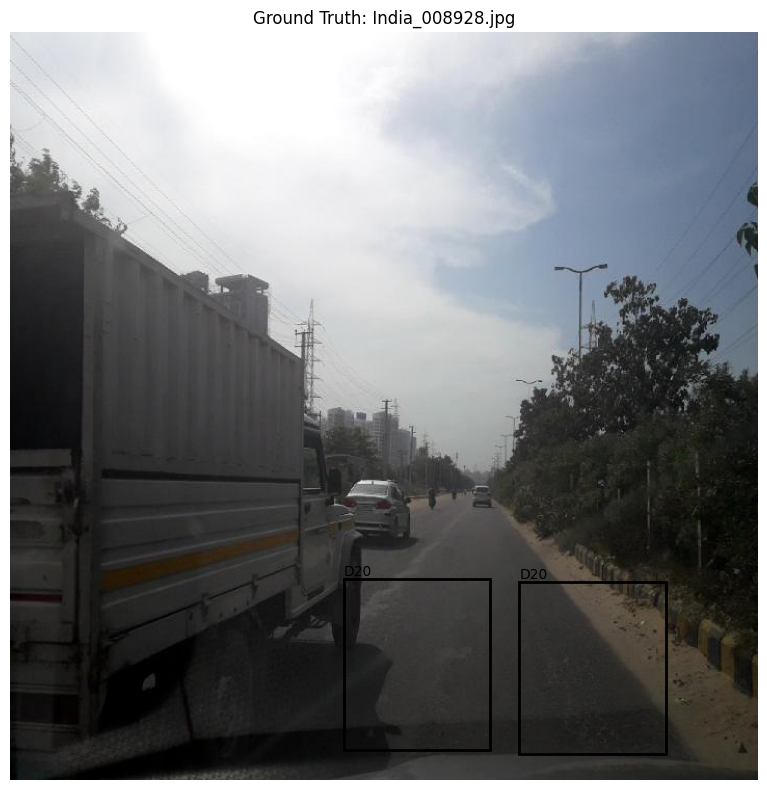

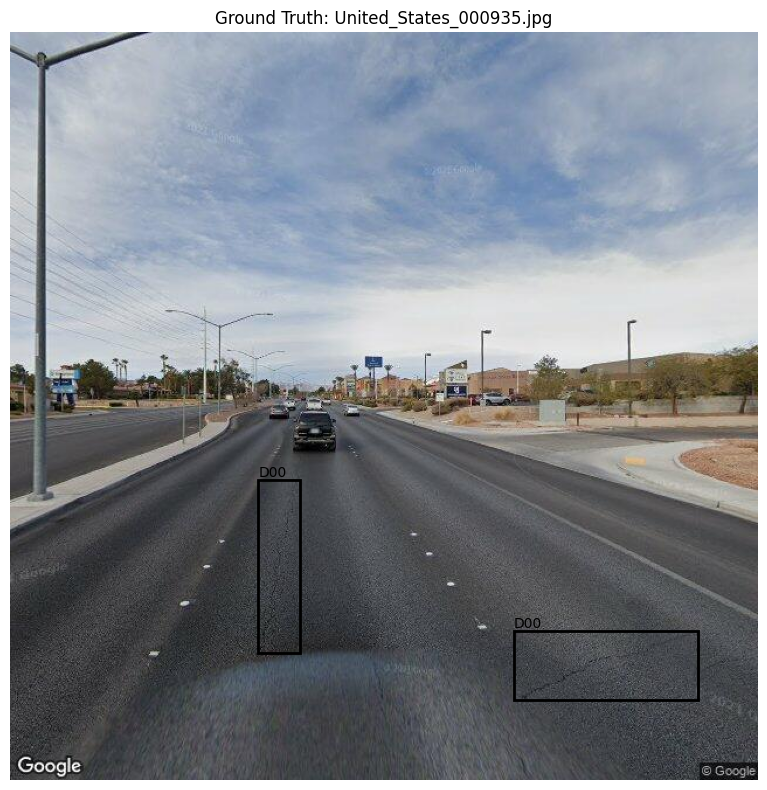

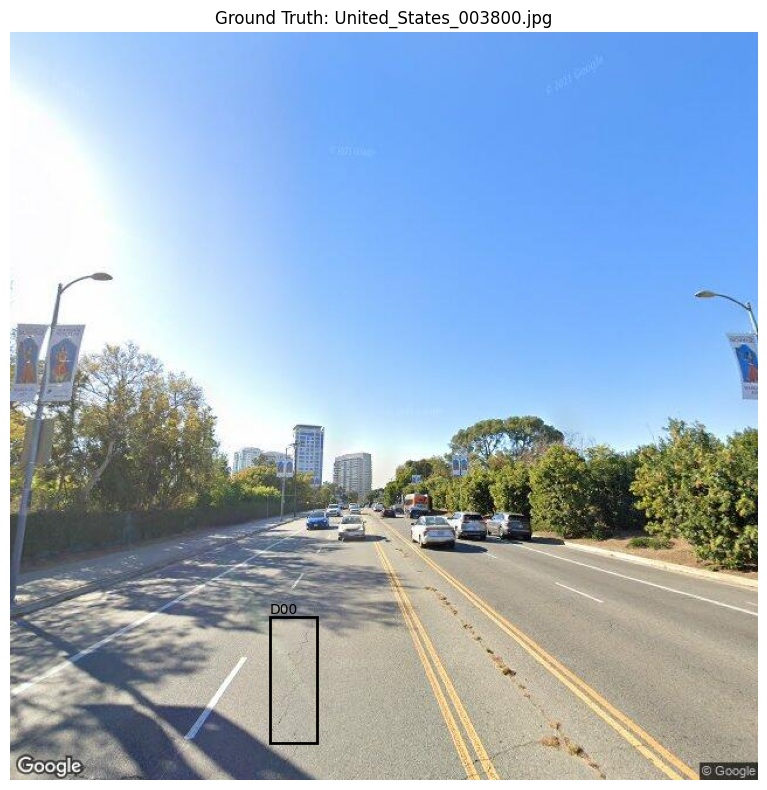

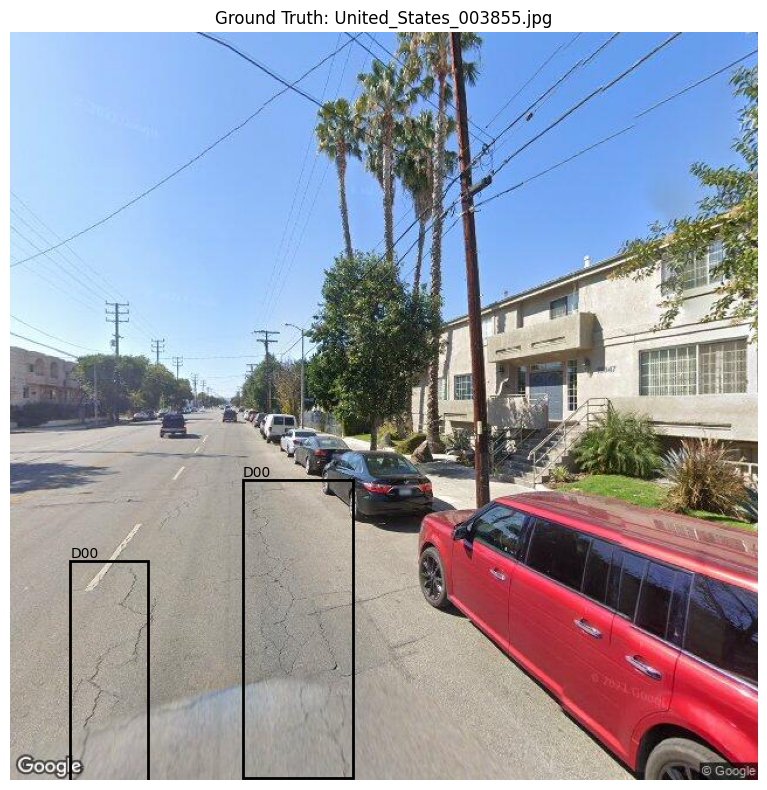

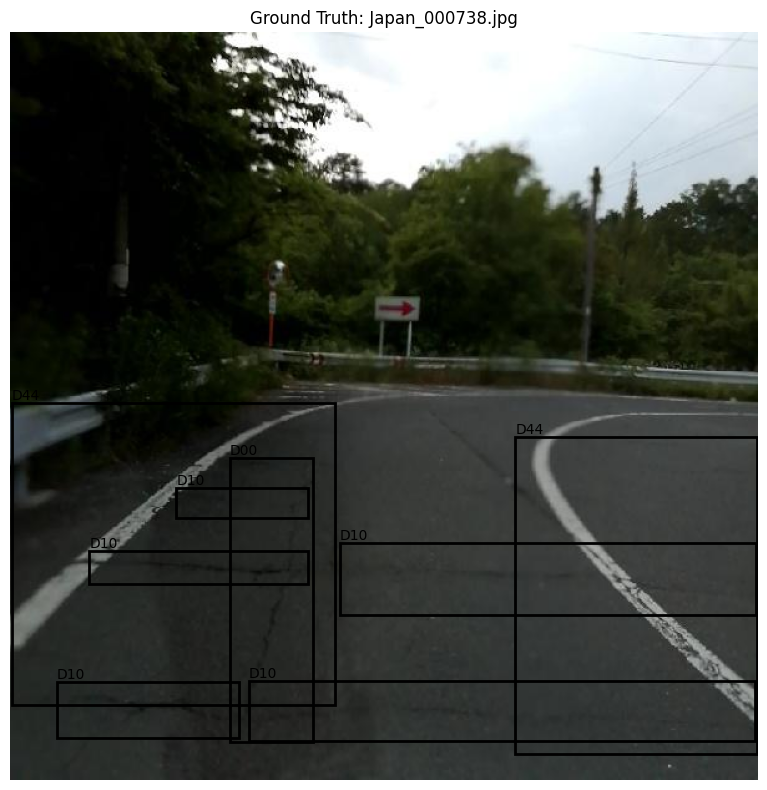

In [28]:
# Display random ground-truth samples for manual annotation verification

sample_filenames = (
    annotations_df["filename"]
    .drop_duplicates()
    .sample(
        n=6,
        random_state=42
    )
    .tolist()
)

for filename in sample_filenames:
    show_ground_truth(filename)

### Ground Truth Validation Results

The visual inspection confirms that the XML annotations represent genuine multi-object detection scenarios.

The inspected samples contain:

- Multiple damage instances within the same image
- Multiple instances of the same damage category
- Multiple damage categories within a single image
- Small damage regions
- Dense annotation scenes with substantial object overlap

The Norway samples are particularly dense, containing a large number of annotated road-damage instances within individual images.

These observations are consistent with the statistical analysis, where 16,443 images contain multiple annotated objects and the maximum number of objects in a single image reaches 44.

## 2.22 Multiple-Damage Visualization

Because more than half of the annotated images contain multiple objects, we explicitly inspect multi-object scenes.

The goal is to verify that each damage instance has its own bounding box and that multiple annotations are correctly represented within the same image.

These samples are also useful for identifying:

- Overlapping boxes
- Dense damage regions
- Very small objects
- Multiple damage categories in one scene

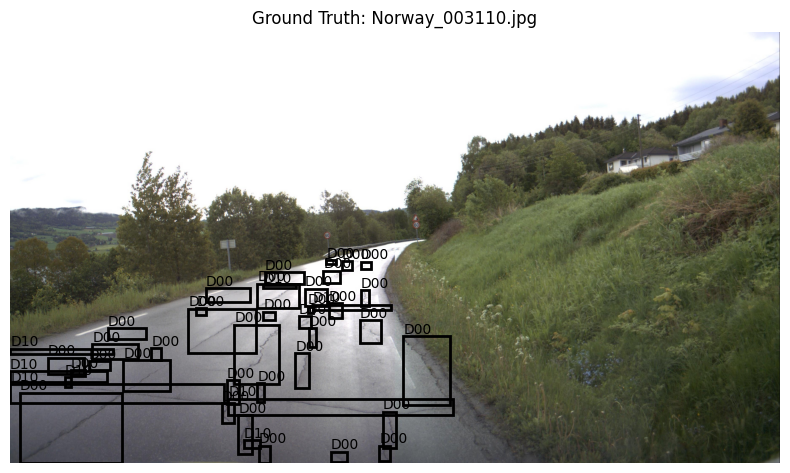

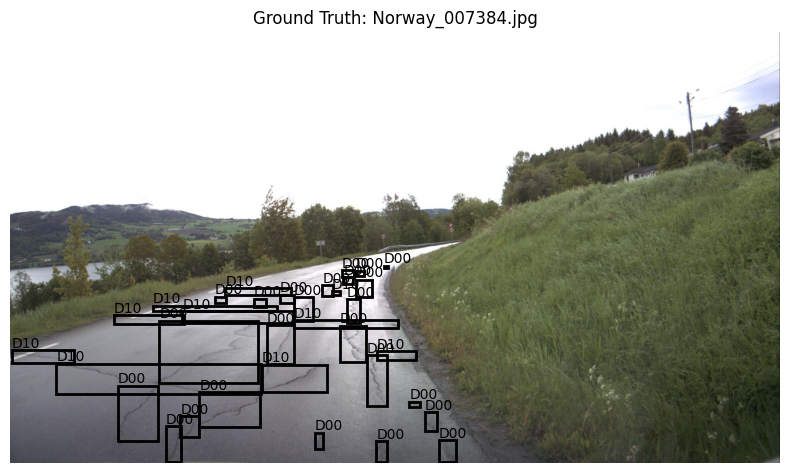

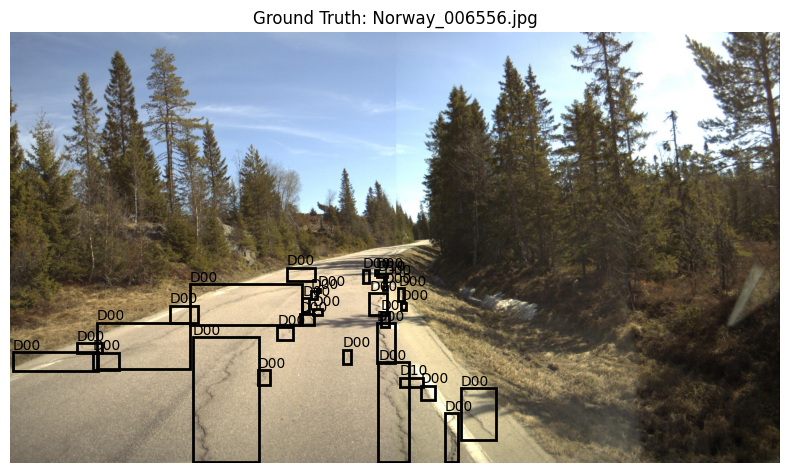

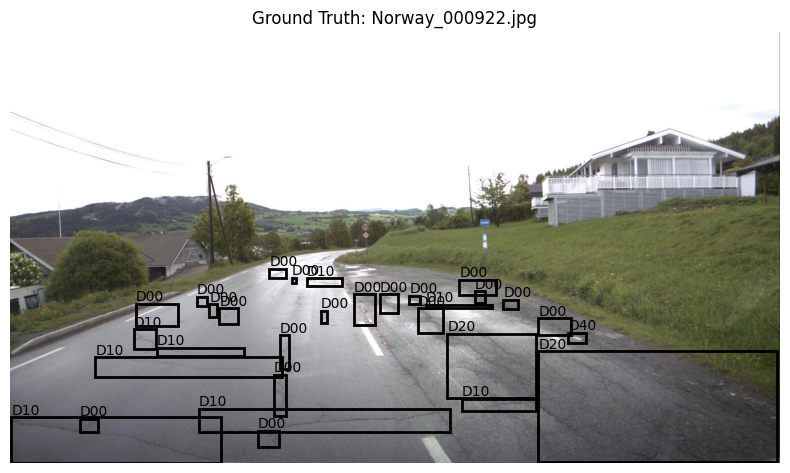

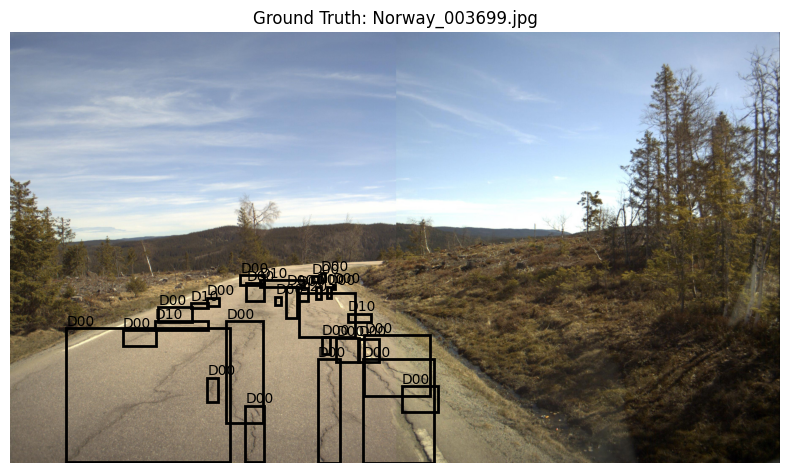

In [29]:
# Display images containing a large number of annotated damage instances

multi_sample_filenames = (
    multi_object_images[
        "filename"
    ]
    .head(5)
    .tolist()
)

for filename in multi_sample_filenames:
    show_ground_truth(filename)

### Annotation Quality Conclusion

The annotation audit provides strong evidence that the dataset is structurally suitable for object detection.

The XML files were successfully parsed into 65,712 object-level records with no remaining parsing errors.

Image-level integrity checks found no missing annotated images and no corrupted or unreadable images.

Visual inspection further confirmed that the annotations represent realistic multi-object road-damage scenes, including images containing multiple damage categories and densely populated annotation regions.

One degenerate bounding box was identified and excluded from the training annotation table without removing its associated image.

The remaining annotations will be used for dataset preparation and conversion into the target object-detection format.